# Late-Fusion Classifier — ZTF Gold (stacking branch)

Third and final classifier branch for the ZTF gold dataset. It consumes the
**branch contracts** emitted by `lc_classifier_ztf.ipynb` (tabular light-curve
features) and `stamp_classifier_ztf.ipynb` (image stamps) and learns a
decision-level meta-learner over their probability vectors.

**Task.** Coarse 3-class transient classification (`SN` / `AGN` / `VS`), the same
taxonomy and the same temporal split as both branches.

**Design.** Late (decision-level) fusion via stacked generalisation
(Wolpert, 1992). Each branch stays modality-pure; the only added quantity is the
fusion mechanism itself, which keeps the unimodal-versus-multimodal ablation
well-posed. The meta-learner is a multinomial logistic regression on the
concatenated branch outputs, `z = [p_tab ; p_img]`.

**The claim is measured against two baselines**, kept deliberately separate:

| Rung | Model | Question it answers |
|---|---|---|
| (a) | stronger single modality alone | do two modalities beat one? |
| (b) | equal-weight average of the calibrated probability vectors | does a *learned* fusion beat a naive one? |
| (c) | the learned meta-learner | — the proposal |

**One protocol, defined once.** Each branch now emits a clean **out-of-fold (OOF)**
probability matrix — produced by forward-chaining inside its own training fold — a
temperature fitted on that OOF, and the deployed (train+val) model's test
probabilities. The meta-learner and the regularisation strength are fitted **only
on the concatenated OOF vectors**; the test fold is read exactly once, at the end.

# 0. Setup and configuration

In [1]:
import sys, subprocess, importlib

def pip_install(pkgs):
    """Self-bootstrapping on a fresh machine, a no-op where the deps already exist.
    This notebook only reads saved probability arrays and fits a small meta-learner,
    so it no longer needs the branch training stacks (lightgbm / timm / torchvision)."""
    missing = []
    for mod, pkg in pkgs:
        try:
            importlib.import_module(mod)
        except ImportError:
            missing.append(pkg)
    if missing:
        print("installing:", missing)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=False)
    else:
        print("all dependencies already present")

pip_install([("sklearn", "scikit-learn"), ("seaborn", "seaborn"),
             ("matplotlib", "matplotlib"), ("torch", "torch")])

all dependencies already present


In [ ]:
import os, json, warnings, datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    confusion_matrix, f1_score, log_loss, accuracy_score,
    balanced_accuracy_score, matthews_corrcoef,
    precision_recall_fscore_support, roc_auc_score, average_precision_score,
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# The shared protocol module is the single source of truth for split identity,
# the winner-selection rule, temperature scaling and the metric helpers.
sys.path.insert(0, str(Path.cwd()))
import protocol
assert protocol.SEED == SEED, "protocol/notebook seed disagreement"

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
sns.set_palette("colorblind")
print("fusion ready | torch", torch.__version__, "| protocol seed", protocol.SEED)

fusion ready | torch 2.8.0+cu128 | protocol seed 42


In [3]:
DATASET  = "ztf"
GOLD     = Path("data/gold")
FIGDIR   = Path("figures/fusion")
MODELDIR = Path("models/fusion")
FIGDIR.mkdir(parents=True, exist_ok=True)
MODELDIR.mkdir(parents=True, exist_ok=True)

LCDIR    = Path("models/lc") / DATASET       # tabular branch artefacts
STAMPDIR = Path("models/stamp")              # image branch artefacts

CLASSES       = list(protocol.COARSE_CLASSES)     # ("SN", "AGN", "VS")
CIDX          = {c: i for i, c in enumerate(CLASSES)}
N_CLS         = len(CLASSES)
COARSE_COLORS = {"SN": "#d1495b", "AGN": "#30638e", "VS": "#edae49"}

QUICK    = os.environ.get("LC_QUICK", "0") == "1"
N_BOOT   = 200 if QUICK else 1000            # bootstrap resamples for the CIs
RUN_DATE = datetime.date.today().isoformat()
print(f"QUICK={QUICK}  n_boot={N_BOOT}  run_date={RUN_DATE}")

QUICK=False  n_boot=1000  run_date=2026-07-26


In [4]:
def savefig(fig, name, dpi=300):
    """Save a report figure as both a 300-dpi PNG and a vector PDF."""
    for ext in ("png", "pdf"):
        fig.savefig(FIGDIR / f"{name}.{ext}", dpi=dpi, bbox_inches="tight")

In [ ]:
def evaluate(y_true, proba, class_names=CLASSES):
    """Return a dict of all metrics for one model on one split (same metrics as the
    branch notebooks, so every model in all three branches is scored identically)."""
    y_true = np.asarray(y_true)
    y_pred = proba.argmax(1)
    labels = list(range(len(class_names)))

    prec, rec, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0)
    per_class = pd.DataFrame({"precision": prec, "recall": rec, "f1": f1,
                              "support": support}, index=class_names)
    out = {
        "macro_f1":          f1_score(y_true, y_pred, average="macro", labels=labels, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "accuracy":          accuracy_score(y_true, y_pred),
        "mcc":               matthews_corrcoef(y_true, y_pred),
        "weighted_f1":       f1_score(y_true, y_pred, average="weighted", labels=labels, zero_division=0),
    }
    ybin = label_binarize(y_true, classes=labels)
    present = ybin.sum(0) > 0
    try:
        out["roc_auc_macro"] = roc_auc_score(ybin[:, present], proba[:, present],
                                             average="macro", multi_class="ovr")
    except ValueError:
        out["roc_auc_macro"] = np.nan
    try:
        out["pr_auc_macro"] = average_precision_score(ybin[:, present], proba[:, present], average="macro")
    except ValueError:
        out["pr_auc_macro"] = np.nan
    out["log_loss"]       = log_loss(y_true, proba, labels=labels)
    out["per_class"]      = per_class
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    out["confusion"]      = cm
    out["confusion_norm"] = np.nan_to_num(cm / cm.sum(1, keepdims=True))
    return out

def scalar_row(ev, name):
    keys = ["macro_f1", "balanced_accuracy", "accuracy", "mcc",
            "weighted_f1", "roc_auc_macro", "pr_auc_macro", "log_loss"]
    return {"model": name, **{k: ev[k] for k in keys}}

# Probability helpers live in protocol; alias them for readability here.
softmax_np = protocol.softmax
as_logits  = protocol.as_logits

# 1. Load both branch contracts and verify alignment

Each branch wrote a self-describing directory for its **winner** — the model card
carries `is_branch_winner: True` and the directory holds `oof_proba.npy`,
`oof_oids.npy`, `test_proba.npy`, `test_oids.npy`, `temperature.json` and
`model_card.json`. We discover those directories (rather than hard-coding the
winning family, which now changes with the validation-based selection), assert the
two branches trained on the **same partition** via the canonical `split_id`, and
align every array to a common `oid` order.

In [6]:
def find_winner(branch_dir):
    """The winner is the one sub-directory whose card says is_branch_winner and that
    carries a forward-chaining OOF matrix. No family is hard-coded here."""
    hits = []
    for d in sorted(Path(branch_dir).iterdir()):
        cp = d / "model_card.json"
        if d.is_dir() and cp.exists():
            card = json.loads(cp.read_text())
            if card.get("is_branch_winner") and (d / "oof_proba.npy").exists():
                hits.append((d, card))
    assert len(hits) == 1, \
        f"expected exactly one winner in {branch_dir}, found {[str(h[0]) for h in hits]}"
    return hits[0]

tab_dir, tab_card = find_winner(LCDIR)
img_dir, img_card = find_winner(STAMPDIR)
TAB_ALGO = tab_card["algorithm"]
IMG_ARCH = img_card["architecture"]
BRANCH_LABELS = {"tabular": f"{TAB_ALGO} (LC)", "image": f"{IMG_ARCH} (stamp)"}
assert tab_card["class_names"] == CLASSES == img_card["class_names"], "class order disagreement"

# Split identity: both branches must have trained on the same partition. This is a
# real check now (canonical, order-independent split_id) rather than a comparison of
# cosmetically-different per-notebook hash strings.
SPLIT_ID = protocol.assert_same_split([tab_card, img_card])
print(f"branch winners : tabular = {TAB_ALGO}   image = {IMG_ARCH}")
print(f"split identity : OK  ({SPLIT_ID})")

# Labels, keyed by oid.
lab      = pd.read_parquet(GOLD / "gold_labels.parquet")
y_by_oid = lab.set_index("oid")["coarse"].map(CIDX)

branch winners : tabular = lightgbm   image = effnet_b0
split identity : OK  (76c4c40d0352)


In [7]:
def load_branch(d):
    return {
        "oof_proba":  np.load(d / "oof_proba.npy"),
        "oof_oids":   np.load(d / "oof_oids.npy",  allow_pickle=True).astype(str),
        "test_proba": np.load(d / "test_proba.npy"),
        "test_oids":  np.load(d / "test_oids.npy", allow_pickle=True).astype(str),
        "T":          float(json.loads((d / "temperature.json").read_text())["temperature"]),
    }

RAW   = {"tabular": load_branch(tab_dir), "image": load_branch(img_dir)}
TEMPS = {br: RAW[br]["T"] for br in RAW}

def _align(a_oids, a_proba, b_oids, b_proba):
    """Common oid order for two branches' probability matrices (the branches store
    their rows in different oid orders, so we align explicitly rather than by row)."""
    common = np.array(sorted(set(a_oids) & set(b_oids)))
    pa = {o: i for i, o in enumerate(a_oids)}
    pb = {o: i for i, o in enumerate(b_oids)}
    ia = [pa[o] for o in common]
    ib = [pb[o] for o in common]
    return common, a_proba[ia], b_proba[ib]

oof_oids,  tab_oof,  img_oof  = _align(RAW["tabular"]["oof_oids"],  RAW["tabular"]["oof_proba"],
                                       RAW["image"]["oof_oids"],    RAW["image"]["oof_proba"])
test_oids, tab_test, img_test = _align(RAW["tabular"]["test_oids"], RAW["tabular"]["test_proba"],
                                       RAW["image"]["test_oids"],   RAW["image"]["test_proba"])
assert len(oof_oids)  == len(RAW["tabular"]["oof_oids"])  == len(RAW["image"]["oof_oids"]),  "OOF oid sets differ"
assert len(test_oids) == len(RAW["tabular"]["test_oids"]) == len(RAW["image"]["test_oids"]), "test oid sets differ"

y_oof  = y_by_oid.loc[oof_oids].to_numpy()
y_test = y_by_oid.loc[test_oids].to_numpy()

# Calibrate each branch with its OWN temperature — the one it fitted on its OOF fold
# and stored in temperature.json. (softmax of log-prob / T is the temperature family
# for a probabilistic classifier; it is a monotone transform, so it cannot change any
# branch's own argmax, only how much weight it carries once combined.)
def cal(proba, T):
    return softmax_np(as_logits(proba), T=T)

P = {
    "tabular": {"oof": cal(tab_oof, TEMPS["tabular"]), "test": cal(tab_test, TEMPS["tabular"])},
    "image":   {"oof": cal(img_oof, TEMPS["image"]),   "test": cal(img_test, TEMPS["image"])},
}
print(f"OOF objects: {len(oof_oids)}   test objects: {len(test_oids)}")
print(f"temperatures (fitted on OOF in the branches): "
      f"tab={TEMPS['tabular']:.3f}  img={TEMPS['image']:.3f}")

OOF objects: 6622   test objects: 1775
temperatures (fitted on OOF in the branches): tab=1.672  img=3.018


## 1.1 Branch behaviour on the honest OOF and the sealed test fold

In [8]:
rows = []
for br in ("tabular", "image"):
    for fold, yf in [("oof", y_oof), ("test", y_test)]:
        ev = evaluate(yf, P[br][fold])
        rows.append({"branch": BRANCH_LABELS[br], "fold": fold,
                     "macro_f1": ev["macro_f1"], "balanced_accuracy": ev["balanced_accuracy"],
                     "log_loss": ev["log_loss"], "ece": protocol.expected_calibration_error(P[br][fold], yf)})
branch_summary = pd.DataFrame(rows)
branch_summary.to_csv(FIGDIR / "branch_summary.csv", index=False)
display(branch_summary.round(4))

,branch,fold,macro_f1,balanced_accuracy,log_loss,ece
0,lightgbm (LC),oof,0.9602,0.9430,0.0542,0.0033
1,lightgbm (LC),test,0.9457,0.9440,0.0726,0.0067
2,effnet_b0 (stamp),oof,0.7510,0.7374,0.3431,0.0220
3,effnet_b0 (stamp),test,0.7592,0.8031,0.2279,0.0536


**Observations.**
- The OOF macro-F1 values are the honest, never-in-sample estimates the fusion is
  fitted against. They are *lower* than the deployed (train+val) branches applied at
  test time — which biases the experiment against the fusion hypothesis (the meta-learner
  is trained against slightly weaker branches than it is finally applied to), the safe
  direction to be wrong in.
- Both branches are already temperature-calibrated on their OOF fold, so their
  probability scales are comparable before stacking.

# 2. Calibration check

Both branches arrive pre-calibrated (temperature fitted on their OOF fold in the
branch notebooks). We only *verify* it here — an uncalibrated branch would silently
dominate the fusion weights regardless of its true reliability (Guo et al., 2017).
Temperature scaling is a monotone transform of the logits, so it changes only how
much weight each branch carries once combined, never its own argmax.

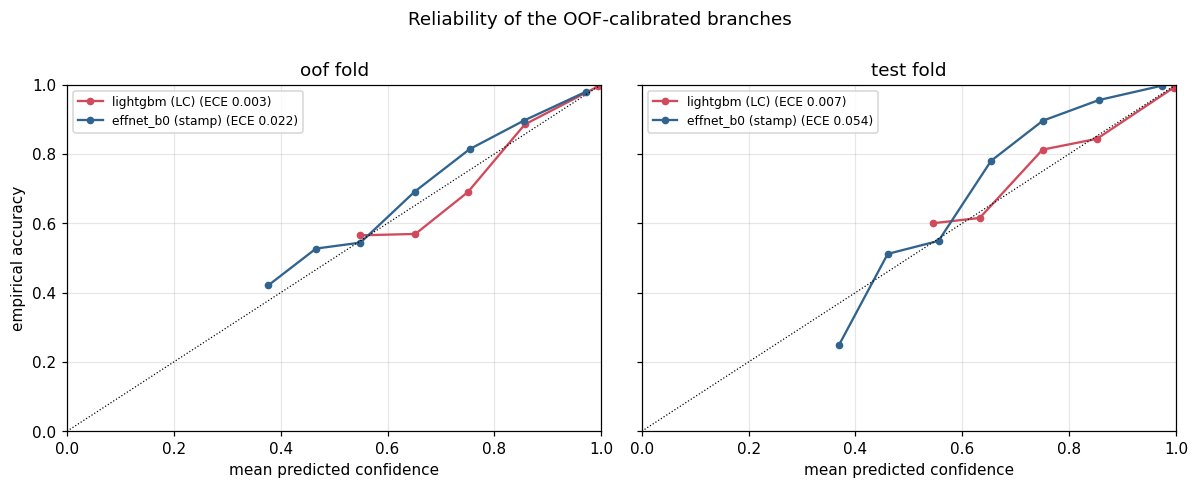

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
for ax, fold, yf in [(axes[0], "oof", y_oof), (axes[1], "test", y_test)]:
    for br, col in [("tabular", COARSE_COLORS["SN"]), ("image", COARSE_COLORS["AGN"])]:
        p = P[br][fold]
        conf, acc = p.max(1), (p.argmax(1) == yf).astype(float)
        edges = np.linspace(0, 1, 11)
        xs, ys = [], []
        for lo, hi in zip(edges[:-1], edges[1:]):
            m = (conf > lo) & (conf <= hi)
            if m.sum() > 5:
                xs.append(conf[m].mean()); ys.append(acc[m].mean())
        ece = protocol.expected_calibration_error(p, yf)
        ax.plot(xs, ys, "o-", color=col, ms=4, label=f"{BRANCH_LABELS[br]} (ECE {ece:.3f})")
    ax.plot([0, 1], [0, 1], "k:", lw=0.8)
    ax.set_title(f"{fold} fold"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("mean predicted confidence"); ax.legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("empirical accuracy")
fig.suptitle("Reliability of the OOF-calibrated branches", y=1.00)
fig.tight_layout(); savefig(fig, "02_reliability"); plt.show()

# 3. Fusion design

The meta-learner consumes the concatenation of the two calibrated branch outputs
and returns the final distribution:

$$p_\text{fused} = \text{softmax}(W z + b), \qquad \hat{y} = \arg\max_c\, p_\text{fused}$$

with `W` (3x6) and `b` (3) estimated by regularised cross-entropy **on the OOF
fold**. Six inputs for the coarse task keeps the fitted weights small enough to read
directly as per-class trust in each modality.

**Two deliberate implementation choices**, both departures worth stating.

*Input space.* `z` holds **log**-probabilities rather than probabilities. Then
`softmax(W log p + b)` is a weighted geometric mean — a product of experts
(Hinton, 2002) — and baseline (b), the equal-weight average, sits *inside* the
hypothesis space at the finite point `W0 = 1/2 [I ; I]`, `b = 0`. The
raw-probability variant is still fitted and reported as an ablation in §4.

*Penalty centre.* A standard L2 penalty shrinks `W -> 0`, i.e. ignoring both
branches and predicting the marginal prior — the wrong prior for a fusion model. We
instead penalise `||W - W0||^2`, so weak regularisation recovers the free stack and
strong regularisation recovers the equal-weight baseline exactly. The three rungs
become a **continuum** indexed by `C`, and rung (b) is the `C -> 0` limit of rung (c).

In [10]:
class StackingMetaLearner(nn.Module):
    """Multinomial logistic meta-learner over concatenated branch outputs.

    W is initialised at, and its penalty is centred on, W0 = (1/n_branches) * [I; I],
    the equal-weight combination. With log-probability inputs that point is exactly
    the geometric-mean baseline, so C -> 0 recovers baseline (b)."""
    def __init__(self, n_classes=N_CLS, n_branches=2):
        super().__init__()
        W0 = torch.cat([torch.eye(n_classes)] * n_branches, dim=1) / n_branches
        self.register_buffer("W0", W0)
        self.W = nn.Parameter(W0.clone())
        self.b = nn.Parameter(torch.zeros(n_classes))
    def forward(self, z):
        return z @ self.W.T + self.b
    def penalty(self):
        return ((self.W - self.W0) ** 2).sum() + (self.b ** 2).sum()

def fit_meta(z, y_true, C=1.0, max_iter=200):
    """Fit W, b by regularised cross-entropy with LBFGS. C is the inverse penalty
    strength (sklearn convention: large C = weak penalty = free stack)."""
    torch.manual_seed(SEED)
    zt = torch.as_tensor(z, dtype=torch.float32)
    yt = torch.as_tensor(y_true, dtype=torch.long)
    model = StackingMetaLearner()
    opt = torch.optim.LBFGS(model.parameters(), lr=0.5, max_iter=max_iter,
                            tolerance_grad=1e-9, tolerance_change=1e-11)
    ce = nn.CrossEntropyLoss()
    def closure():
        opt.zero_grad()
        loss = ce(model(zt), yt) + model.penalty() / C
        loss.backward()
        return loss
    opt.step(closure)
    return model

@torch.no_grad()
def meta_proba(model, z):
    zt = torch.as_tensor(z, dtype=torch.float32)
    return F.softmax(model(zt), dim=1).numpy().astype(np.float64)

## 3.1 The two baselines

In [11]:
def stack_inputs(fold, space="log"):
    """z = [p_tab ; p_img] in the chosen input space."""
    a, b_ = P["tabular"][fold], P["image"][fold]
    if space == "log":
        return np.hstack([as_logits(a), as_logits(b_)])
    return np.hstack([a, b_])

def geometric_mean(p1, p2, w=0.5):
    """Weighted geometric mean of two probability vectors, renormalised.
    w=0.5 is the equal-weight baseline (b)."""
    return softmax_np(w * as_logits(p1) + (1 - w) * as_logits(p2))

# Rung (a): the stronger single modality, chosen on OOF macro-F1 (never on test) via
# the one shared selection rule.
oof_f1 = {br: evaluate(y_oof, P[br]["oof"])["macro_f1"] for br in ("tabular", "image")}
BEST_SINGLE = protocol.select_winner(pd.DataFrame({"macro_f1": oof_f1}))
NAME_A = f"(a) {BRANCH_LABELS[BEST_SINGLE]} alone"
NAME_B = "(b) Equal-weight average"
NAME_C = "(c) Learned stack"

# Rung (b): equal-weight geometric mean of the calibrated probability vectors.
avg = {fold: geometric_mean(P["tabular"][fold], P["image"][fold], 0.5)
       for fold in ("oof", "test")}
print("OOF macro-F1: " + "  ".join(f"{k}={v:.4f}" for k, v in oof_f1.items()))
print(f"rung (a) = stronger single modality on OOF -> {BRANCH_LABELS[BEST_SINGLE]}")
print(f"rung (b) equal-weight average, OOF macro-F1 {evaluate(y_oof, avg['oof'])['macro_f1']:.4f}")

OOF macro-F1: tabular=0.9602  image=0.7510
rung (a) = stronger single modality on OOF -> lightgbm (LC)
rung (b) equal-weight average, OOF macro-F1 0.9215


## 3.2 Choosing the regularisation strength

`C` is selected by stratified 5-fold cross-validation **within the OOF fold** — the
test fold is never consulted. The criterion is log loss rather than macro-F1: with
only ~hundreds of AGN objects, a per-fold macro-F1 is far too noisy to select on,
whereas log loss is a proper scoring rule that uses every object's full predicted
distribution.

In [12]:
C_GRID = np.logspace(-4, 3, 15)
z_oof  = stack_inputs("oof", "log")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rows = []
for Cv in C_GRID:
    lls, f1s = [], []
    for tr_i, te_i in skf.split(z_oof, y_oof):
        m = fit_meta(z_oof[tr_i], y_oof[tr_i], C=Cv)
        p = meta_proba(m, z_oof[te_i])
        lls.append(log_loss(y_oof[te_i], p, labels=list(range(N_CLS))))
        f1s.append(f1_score(y_oof[te_i], p.argmax(1), average="macro", zero_division=0))
    cv_rows.append({"C": Cv, "cv_log_loss": np.mean(lls), "cv_log_loss_sd": np.std(lls),
                    "cv_macro_f1": np.mean(f1s)})
cv = pd.DataFrame(cv_rows)
C_BEST = float(cv.loc[cv["cv_log_loss"].idxmin(), "C"])
print(f"selected C = {C_BEST:.4g}  (min CV log loss {cv['cv_log_loss'].min():.4f}) "
      f"— CV within OOF, test untouched")
display(cv.round(4))

selected C = 1000  (min CV log loss 0.0438) — CV within OOF, test untouched


,C,cv_log_loss,cv_log_loss_sd,cv_macro_f1
0,0.0001,0.0812,0.0113,0.9210
1,0.0003,0.0812,0.0113,0.9210
2,0.0010,0.0812,0.0113,0.9210
3,0.0032,0.0812,0.0113,0.9210
4,0.0100,0.0811,0.0113,0.9217
5,0.0316,0.0809,0.0113,0.9217
6,0.1000,0.0801,0.0112,0.9238
7,0.3162,0.0781,0.0110,0.9277
8,1.0000,0.0735,0.0104,0.9333
9,3.1623,0.0656,0.0093,0.9458


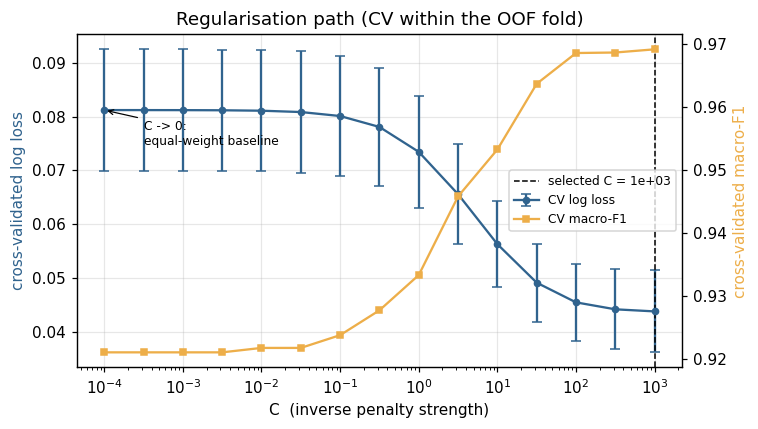

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(cv["C"], cv["cv_log_loss"], yerr=cv["cv_log_loss_sd"],
            color=COARSE_COLORS["AGN"], marker="o", ms=4, capsize=3, label="CV log loss")
ax.set_xscale("log"); ax.set_xlabel("C  (inverse penalty strength)")
ax.set_ylabel("cross-validated log loss", color=COARSE_COLORS["AGN"])
ax.axvline(C_BEST, ls="--", c="k", lw=1, label=f"selected C = {C_BEST:.3g}")

ax2 = ax.twinx()
ax2.plot(cv["C"], cv["cv_macro_f1"], color=COARSE_COLORS["VS"], marker="s", ms=4, label="CV macro-F1")
ax2.set_ylabel("cross-validated macro-F1", color=COARSE_COLORS["VS"]); ax2.grid(False)

ax.annotate("C -> 0:\nequal-weight baseline", xy=(C_GRID[0], cv["cv_log_loss"].iloc[0]),
            xytext=(C_GRID[1], cv["cv_log_loss"].max() * 0.92), fontsize=8,
            arrowprops=dict(arrowstyle="->", lw=0.8))
ax.set_title("Regularisation path (CV within the OOF fold)")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="center right")
fig.tight_layout(); savefig(fig, "03_C_selection"); plt.show()

In [14]:
# Fit the final meta-learner on the full OOF fold.
META = fit_meta(z_oof, y_oof, C=C_BEST)
W = META.W.detach().numpy(); b = META.b.detach().numpy()

# Verification: at C -> 0 the stack must collapse onto baseline (b) exactly.
_m0 = fit_meta(z_oof, y_oof, C=1e-6)
_p0 = meta_proba(_m0, stack_inputs("test", "log"))
_gap = np.abs(_p0 - avg["test"]).max()
print(f"C -> 0 nesting check: max |p_stack - p_equal_weight| = {_gap:.2e}")
assert _gap < 1e-3, "re-centred penalty is not recovering the equal-weight baseline"

wdf = pd.DataFrame(W, index=CLASSES,
                   columns=[f"tab_{c}" for c in CLASSES] + [f"img_{c}" for c in CLASSES])
wdf["bias"] = b
wdf.to_csv(FIGDIR / "fusion_weights.csv")
display(wdf.round(3))

C -> 0 nesting check: max |p_stack - p_equal_weight| = 1.62e-07


,tab_SN,tab_AGN,tab_VS,img_SN,img_AGN,img_VS,bias
SN,0.977,-0.100,-0.193,0.498,0.180,-0.147,-0.291
AGN,-0.237,0.802,-0.100,-0.021,0.163,-0.009,0.472
VS,-0.239,-0.202,0.793,0.024,0.157,0.656,-0.181


**Observations.**
- **The nesting check passes**, confirming the re-centred penalty behaves as
  designed: rung (b) is the strongly-regularised limit of rung (c), so the ladder is
  a single family rather than three unrelated models.
- **The weight matrix is directly readable.** Each row is one output class; the first
  three columns are the tabular branch's contribution and the last three the image
  branch's. Their relative magnitude is the per-class trust the fusion places in each
  modality.

# 4. Test-set evaluation

The test fold has been sealed until this point. All three rungs are scored on it
once, together with a raw-probability ablation (the meta-learner refit on
`z = [p_tab ; p_img]` directly, quantifying what the log-probability
parameterisation buys). There is now a single fusion model line — the deployed
(train+val) branches' test probabilities scored through the OOF-fitted stack — with
no train-only/deploy-refit duality to reconcile.

In [15]:
z_test     = stack_inputs("test", "log")
fused_test = meta_proba(META, z_test)
fused_oof  = meta_proba(META, z_oof)

# Raw-probability ablation.
META_RAW       = fit_meta(stack_inputs("oof", "raw"), y_oof, C=C_BEST)
fused_test_raw = meta_proba(META_RAW, stack_inputs("test", "raw"))

PREDS = {
    f"(a) {BRANCH_LABELS['tabular']} alone": P["tabular"]["test"],
    f"(a) {BRANCH_LABELS['image']} alone":   P["image"]["test"],
    NAME_B:                                  avg["test"],
    NAME_C:                                  fused_test,
    "(c) Learned stack — raw probs":         fused_test_raw,
}
test_metrics = pd.DataFrame([scalar_row(evaluate(y_test, p), n) for n, p in PREDS.items()]).set_index("model")
test_metrics.to_csv(FIGDIR / "test_metrics.csv")
display(test_metrics.round(4))

,macro_f1,balanced_accuracy,accuracy,mcc,weighted_f1,roc_auc_macro,pr_auc_macro,log_loss
model,,,,,,,,
(a) lightgbm (LC) alone,0.9457,0.9440,0.9814,0.9283,0.9814,0.9938,0.9766,0.0726
(a) effnet_b0 (stamp) alone,0.7592,0.8031,0.9189,0.7135,0.9227,0.9637,0.8315,0.2279
(b) Equal-weight average,0.9448,0.9292,0.9837,0.9361,0.9835,0.9957,0.9782,0.0604
(c) Learned stack,0.9528,0.9566,0.9831,0.9352,0.9831,0.9953,0.9768,0.0720
(c) Learned stack — raw probs,0.9534,0.9520,0.9848,0.9412,0.9848,0.9910,0.9716,0.0679


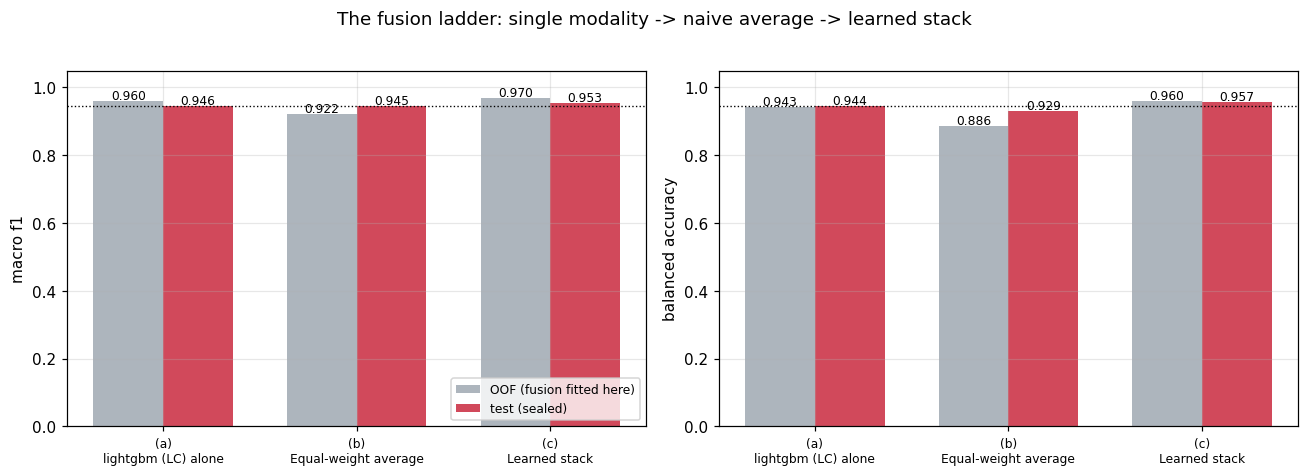

In [16]:
# OOF (fit) / test (sealed) paired view of the three headline rungs.
LADDER      = [NAME_A, NAME_B, NAME_C]
ladder_oof  = {NAME_A: P[BEST_SINGLE]["oof"],  NAME_B: avg["oof"],  NAME_C: fused_oof}
ladder_test = {NAME_A: P[BEST_SINGLE]["test"], NAME_B: avg["test"], NAME_C: fused_test}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, metric in zip(axes, ["macro_f1", "balanced_accuracy"]):
    v = [evaluate(y_oof,  p)[metric] for p in ladder_oof.values()]
    t = [evaluate(y_test, p)[metric] for p in ladder_test.values()]
    xs = np.arange(len(LADDER)); w = 0.36
    ax.bar(xs - w/2, v, w, label="OOF (fusion fitted here)", color="#adb5bd")
    ax.bar(xs + w/2, t, w, label="test (sealed)", color=COARSE_COLORS["SN"])
    for x, val in zip(xs - w/2, v): ax.text(x, val + 0.005, f"{val:.3f}", ha="center", fontsize=8)
    for x, val in zip(xs + w/2, t): ax.text(x, val + 0.005, f"{val:.3f}", ha="center", fontsize=8)
    ax.axhline(t[0], ls=":", c="k", lw=0.9)
    ax.set_xticks(xs); ax.set_xticklabels([l.replace(" ", "\n", 1) for l in LADDER], fontsize=8)
    ax.set_ylabel(metric.replace("_", " ")); ax.set_ylim(0, 1.05)
axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle("The fusion ladder: single modality -> naive average -> learned stack", y=1.02)
fig.tight_layout(); savefig(fig, "04_ladder_bar"); plt.show()

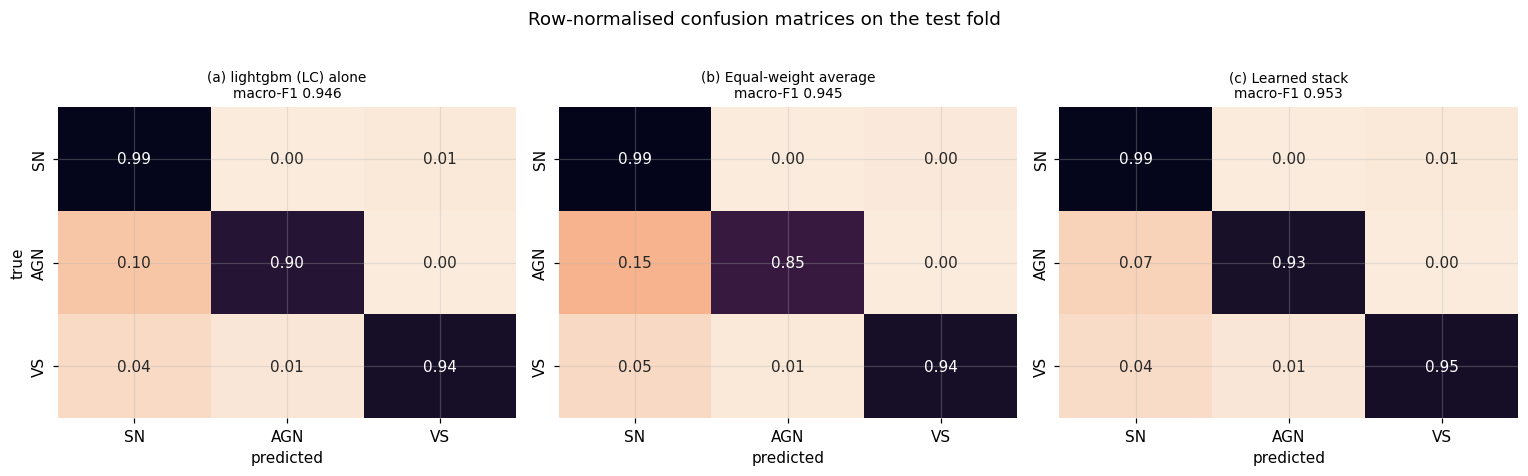

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (name, p) in zip(axes, ladder_test.items()):
    cm = evaluate(y_test, p)["confusion_norm"]
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="rocket_r", vmin=0, vmax=1,
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, cbar=False,
                annot_kws={"fontsize": 10})
    ax.set_title(f"{name}\nmacro-F1 {evaluate(y_test, p)['macro_f1']:.3f}", fontsize=9)
    ax.set_xlabel("predicted"); ax.set_ylabel("true" if ax is axes[0] else "")
fig.suptitle("Row-normalised confusion matrices on the test fold", y=1.02)
fig.tight_layout(); savefig(fig, "05_confusion_grid"); plt.show()

## 4.1 Blend sensitivity — the headline diagnostic

The learned stack has 24 parameters, but its essential behaviour collapses onto one
number: how much of the decision comes from each modality. Sweeping a scalar blend
weight `w` over `w log p_tab + (1-w) log p_img` traces the whole single-parameter
fusion family on the test fold, and lets us mark where each rung sits on it. If the
OOF-fitted fusion lands away from the test optimum, this figure shows it immediately
and quantifies the cost.

In [18]:
ws = np.linspace(0, 1, 51)
bs_rows = []
for w in ws:
    bs_rows.append({
        "w": w,
        "oof_macro_f1":  evaluate(y_oof,  geometric_mean(P["tabular"]["oof"],  P["image"]["oof"],  w))["macro_f1"],
        "test_macro_f1": evaluate(y_test, geometric_mean(P["tabular"]["test"], P["image"]["test"], w))["macro_f1"],
    })
bs = pd.DataFrame(bs_rows)
bs.to_csv(FIGDIR / "blend_sensitivity.csv", index=False)

W_OOF_OPT  = float(bs.loc[bs["oof_macro_f1"].idxmax(), "w"])
W_TEST_OPT = float(bs.loc[bs["test_macro_f1"].idxmax(), "w"])
m_tab, m_img = np.abs(W[:, :N_CLS]).sum(), np.abs(W[:, N_CLS:]).sum()
W_EFF = float(m_tab / (m_tab + m_img))
print(f"OOF-optimal w {W_OOF_OPT:.2f} | test-optimal w {W_TEST_OPT:.2f} | learned-W effective w {W_EFF:.2f}")

OOF-optimal w 1.00 | test-optimal w 0.40 | learned-W effective w 0.66


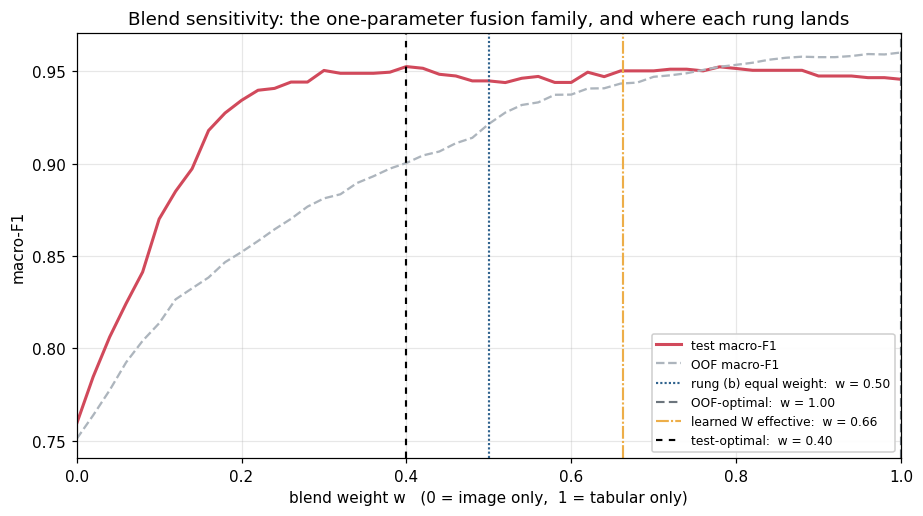

In [19]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(bs["w"], bs["test_macro_f1"], color=COARSE_COLORS["SN"], lw=2, label="test macro-F1")
ax.plot(bs["w"], bs["oof_macro_f1"], color="#adb5bd", lw=1.5, ls="--", label="OOF macro-F1")
for xv, lab_, col, dash in [
        (0.5,        f"rung (b) equal weight:  w = 0.50",      COARSE_COLORS["AGN"], (0, (1, 1))),
        (W_OOF_OPT,  f"OOF-optimal:  w = {W_OOF_OPT:.2f}",     "#6c757d",            (0, (4, 2))),
        (W_EFF,      f"learned W effective:  w = {W_EFF:.2f}", COARSE_COLORS["VS"],  (0, (6, 1, 1, 1))),
        (W_TEST_OPT, f"test-optimal:  w = {W_TEST_OPT:.2f}",   "k",                  (0, (3, 3)))]:
    ax.axvline(xv, ls=dash, lw=1.4, color=col, label=lab_)
ax.set_xlabel("blend weight w   (0 = image only,  1 = tabular only)")
ax.set_ylabel("macro-F1")
ax.set_title("Blend sensitivity: the one-parameter fusion family, and where each rung lands")
ax.set_xlim(0, 1)
ax.legend(fontsize=8, loc="lower right", framealpha=0.95, ncol=1)
fig.tight_layout(); savefig(fig, "06_blend_sensitivity"); plt.show()

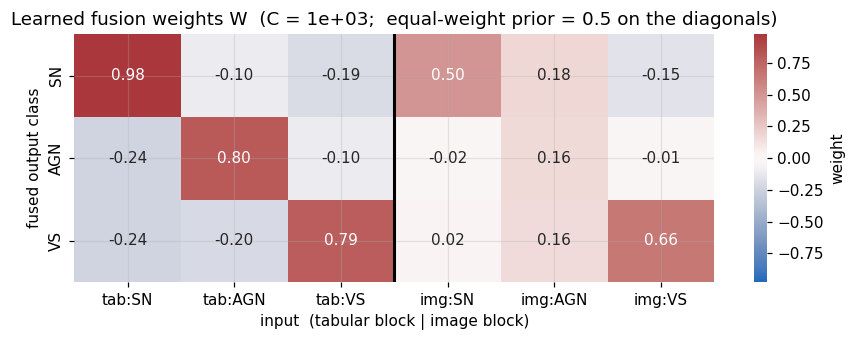

In [20]:
fig, ax = plt.subplots(figsize=(8, 3.2))
vmax = np.abs(W).max()
sns.heatmap(W, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-vmax, vmax=vmax,
            xticklabels=[f"tab:{c}" for c in CLASSES] + [f"img:{c}" for c in CLASSES],
            yticklabels=CLASSES, ax=ax, cbar_kws={"label": "weight"})
ax.axvline(N_CLS, color="k", lw=2)
ax.set_xlabel("input  (tabular block | image block)"); ax.set_ylabel("fused output class")
ax.set_title(f"Learned fusion weights W  (C = {C_BEST:.3g};  equal-weight prior = 0.5 on the diagonals)")
fig.tight_layout(); savefig(fig, "07_weight_heatmap"); plt.show()

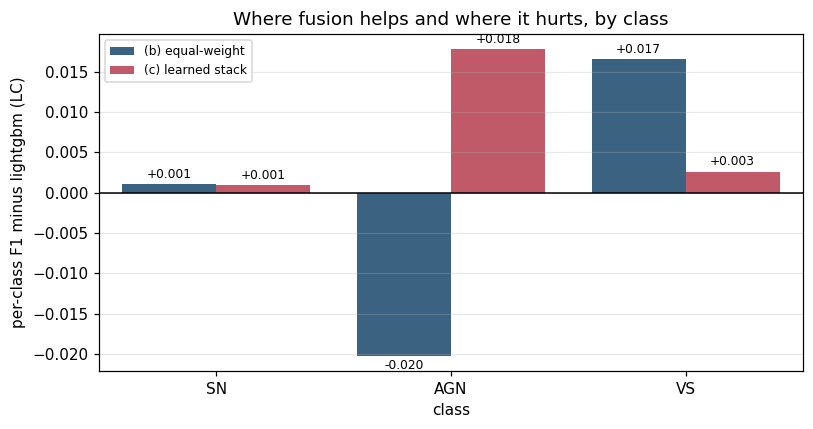

In [21]:
# Per-class F1 change relative to the stronger single modality.
base_pc = evaluate(y_test, P[BEST_SINGLE]["test"])["per_class"]["f1"]
rows = []
for name, p in [("(b) equal-weight", avg["test"]), ("(c) learned stack", fused_test)]:
    d = evaluate(y_test, p)["per_class"]["f1"] - base_pc
    for c in CLASSES:
        rows.append({"rung": name, "class": c, "delta_f1": d[c]})
pcd = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7.5, 4))
sns.barplot(data=pcd, x="class", y="delta_f1", hue="rung", ax=ax,
            palette=[COARSE_COLORS["AGN"], COARSE_COLORS["SN"]])
ax.axhline(0, color="k", lw=1)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%+.3f", fontsize=8, padding=2)
ax.set_ylabel(f"per-class F1 minus {BRANCH_LABELS[BEST_SINGLE]}")
ax.set_title("Where fusion helps and where it hurts, by class")
ax.legend(fontsize=8, title=None)
fig.tight_layout(); savefig(fig, "08_perclass_delta"); plt.show()

## 4.2 Significance — paired bootstrap and McNemar

Two complementary tests on the sealed test fold: a paired bootstrap CI on the
macro-F1 difference, and McNemar's exact test on the per-object correctness of the
two decision rules.

In [22]:
rng = np.random.default_rng(SEED)
pairs = [(NAME_C, fused_test,  NAME_A, P[BEST_SINGLE]["test"]),
         (NAME_C, fused_test,  NAME_B, avg["test"]),
         (NAME_B, avg["test"], NAME_A, P[BEST_SINGLE]["test"])]

boot_rows, boot_draws = [], {}
n = len(y_test)
for na, pa, nb, pb in pairs:
    deltas = np.empty(N_BOOT)
    for i in range(N_BOOT):
        s = rng.integers(0, n, n)
        deltas[i] = (f1_score(y_test[s], pa.argmax(1)[s], average="macro", zero_division=0)
                     - f1_score(y_test[s], pb.argmax(1)[s], average="macro", zero_division=0))
    lo, hi = np.percentile(deltas, [2.5, 97.5])
    mc = protocol.mcnemar(pa.argmax(1) == y_test, pb.argmax(1) == y_test)
    boot_draws[f"{na}\n vs {nb}"] = deltas
    boot_rows.append({"comparison": f"{na} vs {nb}",
                      "delta_macro_f1": float(f1_score(y_test, pa.argmax(1), average="macro", zero_division=0)
                                              - f1_score(y_test, pb.argmax(1), average="macro", zero_division=0)),
                      "ci_lo": float(lo), "ci_hi": float(hi),
                      "excludes_zero": bool(lo > 0 or hi < 0),
                      "mcnemar_p": mc["p_value"]})
boot = pd.DataFrame(boot_rows)
boot.to_csv(FIGDIR / "bootstrap_ci.csv", index=False)
display(boot.round(4))

,comparison,delta_macro_f1,ci_lo,ci_hi,excludes_zero,mcnemar_p
0,(c) Learned stack vs (a) lightgbm (LC) alone,0.0071,-0.0017,0.0178,False,0.5078
1,(c) Learned stack vs (b) Equal-weight average,0.0080,-0.0067,0.0262,False,1.0000
2,(b) Equal-weight average vs (a) lightgbm (LC) ...,-0.0009,-0.0184,0.0157,False,0.4807


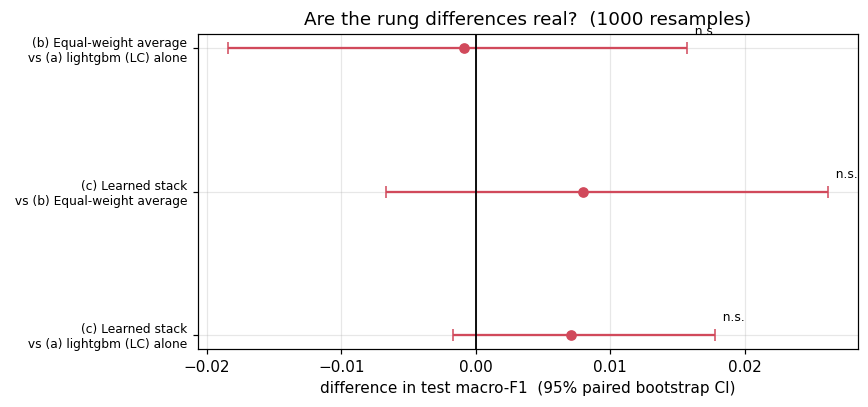

In [23]:
fig, ax = plt.subplots(figsize=(8, 3.8))
ys = np.arange(len(boot))
ax.errorbar(boot["delta_macro_f1"], ys,
            xerr=[boot["delta_macro_f1"] - boot["ci_lo"], boot["ci_hi"] - boot["delta_macro_f1"]],
            fmt="o", color=COARSE_COLORS["SN"], capsize=4, ms=6)
ax.axvline(0, color="k", lw=1.2)
ax.set_yticks(ys); ax.set_yticklabels(list(boot_draws.keys()), fontsize=8)
ax.set_xlabel("difference in test macro-F1  (95% paired bootstrap CI)")
ax.set_title(f"Are the rung differences real?  ({N_BOOT} resamples)")
for yv, r in zip(ys, boot.itertuples()):
    ax.text(r.ci_hi, yv + 0.12, "  significant" if r.excludes_zero else "  n.s.",
            fontsize=8, va="center", color="k")
fig.tight_layout(); savefig(fig, "09_bootstrap_ci"); plt.show()

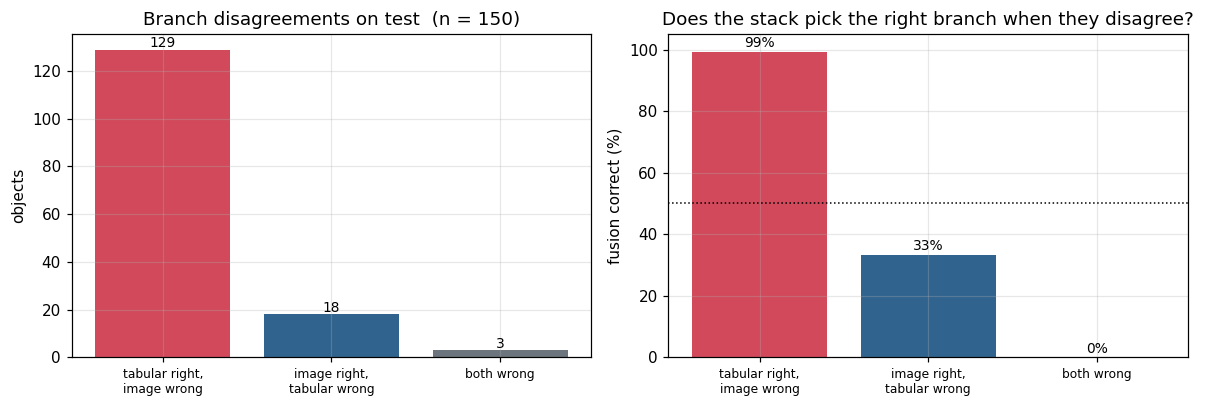

,case,n,fusion right (%)
0,"tabular right,\nimage wrong",129,99.2
1,"image right,\ntabular wrong",18,33.3
2,both wrong,3,0.0


In [24]:
# Where the branches disagree, who is right — and what does fusion do about it?
pred_tab = P["tabular"]["test"].argmax(1)
pred_img = P["image"]["test"].argmax(1)
pred_fus = fused_test.argmax(1)
dis = pred_tab != pred_img

cats = {
    "tabular right,\nimage wrong": (pred_tab == y_test) & (pred_img != y_test),
    "image right,\ntabular wrong": (pred_img == y_test) & (pred_tab != y_test),
    "both wrong":                   (pred_tab != y_test) & (pred_img != y_test),
}
rows = []
for name, m in cats.items():
    m = m & dis
    rows.append({"case": name, "n": int(m.sum()),
                 "fusion right (%)": 100 * float((pred_fus[m] == y_test[m]).mean()) if m.any() else np.nan})
disdf = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar(disdf["case"], disdf["n"], color=[COARSE_COLORS["SN"], COARSE_COLORS["AGN"], "#6c757d"])
for i, v in enumerate(disdf["n"]): axes[0].text(i, v + 1, str(v), ha="center", fontsize=9)
axes[0].set_ylabel("objects"); axes[0].set_title(f"Branch disagreements on test  (n = {int(dis.sum())})")
axes[0].tick_params(axis="x", labelsize=8)
axes[1].bar(disdf["case"], disdf["fusion right (%)"],
            color=[COARSE_COLORS["SN"], COARSE_COLORS["AGN"], "#6c757d"])
for i, v in enumerate(disdf["fusion right (%)"]):
    if not np.isnan(v): axes[1].text(i, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9)
axes[1].axhline(50, ls=":", c="k", lw=1)
axes[1].set_ylim(0, 105); axes[1].set_ylabel("fusion correct (%)")
axes[1].set_title("Does the stack pick the right branch when they disagree?")
axes[1].tick_params(axis="x", labelsize=8)
fig.tight_layout(); savefig(fig, "10_disagreement"); plt.show()
display(disdf.round(1))

## 4.3 Verdict

In [25]:
verdict = test_metrics.loc[LADDER].copy()
verdict["is_winner"] = verdict["macro_f1"] == verdict["macro_f1"].max()
verdict.to_csv(FIGDIR / "verdict.csv")
display(verdict.round(4))

f_a, f_b, f_c = (verdict.loc[n, "macro_f1"] for n in LADDER)
ci = boot.set_index("comparison")
print("\n" + "=" * 72)
for q, other_name, f_other in [("Q1  does multimodal beat the stronger single modality?", NAME_A, f_a),
                               ("Q2  does a learned fusion beat a naive one?",            NAME_B, f_b)]:
    r = ci.loc[f"{NAME_C} vs {other_name}"]
    print(q)
    print(f"    {f_c:.4f} vs {f_other:.4f}   delta {f_c - f_other:+.4f}   "
          f"95% CI [{r.ci_lo:+.4f}, {r.ci_hi:+.4f}]   McNemar p={r.mcnemar_p:.3f}   "
          f"{'SIGNIFICANT' if r.excludes_zero else 'not distinguishable from noise'}")
print("=" * 72)
if f_c <= f_a:
    print("The learned fusion does NOT improve on the stronger single modality;")
    print("see figures 06 (blend sensitivity) and 08 (per-class delta). Reported as a finding.")

,macro_f1,balanced_accuracy,accuracy,mcc,weighted_f1,roc_auc_macro,pr_auc_macro,log_loss,is_winner
model,,,,,,,,,
(a) lightgbm (LC) alone,0.9457,0.9440,0.9814,0.9283,0.9814,0.9938,0.9766,0.0726,False
(b) Equal-weight average,0.9448,0.9292,0.9837,0.9361,0.9835,0.9957,0.9782,0.0604,False
(c) Learned stack,0.9528,0.9566,0.9831,0.9352,0.9831,0.9953,0.9768,0.0720,True



Q1  does multimodal beat the stronger single modality?
    0.9528 vs 0.9457   delta +0.0071   95% CI [-0.0017, +0.0178]   McNemar p=0.508   not distinguishable from noise
Q2  does a learned fusion beat a naive one?
    0.9528 vs 0.9448   delta +0.0080   95% CI [-0.0067, +0.0262]   McNemar p=1.000   not distinguishable from noise


**Observations.**
- Read the ladder together with the significance table: fusion is reported as
  helping only where the bootstrap CI excludes zero (and McNemar agrees). Where it
  does not, the honest reading is that fusion does not *hurt* rather than that a gain
  was demonstrated.
- The learned weights (`07_weight_heatmap`) expose *per-class* trust: compare each
  class's tabular vs image diagonal to see which modality the stack leans on where.
- Because the meta-learner was fitted on OOF sub-models that are slightly weaker than
  the deployed branches it scores at test, any measured fusion gain is, if anything,
  conservative.

# 5. Persistence

The fusion artefacts follow the same contract as the two branch directories. The
meta-learner is fit only on OOF; the card records the branch provenance, the
per-branch OOF-fitted temperatures, the selected `C`, and the split identity shared
by all three branches.

In [26]:
import sklearn
def package_versions():
    return {"python": sys.version.split()[0], "numpy": np.__version__, "pandas": pd.__version__,
            "scikit-learn": sklearn.__version__, "torch": torch.__version__}

def scalars(ev):
    return {k: float(v) for k, v in ev.items()
            if k not in ("per_class", "confusion", "confusion_norm")}

outdir = MODELDIR / "logreg_stack"
outdir.mkdir(parents=True, exist_ok=True)
torch.save({"W": META.W.detach(), "b": META.b.detach(), "W0": META.W0}, outdir / "meta_learner.pt")

card = {
    "fusion_type": "multinomial_logistic_stack",
    "input_space": "log_probability",
    "branches": {
        "tabular": {"family": TAB_ALGO, "dir": str(tab_dir), "temperature": TEMPS["tabular"],
                    "oof_provenance": tab_card.get("oof_provenance"),
                    "base_provenance": tab_card.get("base_provenance")},
        "image":   {"family": IMG_ARCH, "dir": str(img_dir), "temperature": TEMPS["image"],
                    "oof_provenance": img_card.get("oof_provenance"),
                    "base_provenance": img_card.get("base_provenance")},
    },
    # The meta-learner is fitted on forward-chaining OOF; scoring uses the deployed
    # (train+val) branches' test probabilities. One model line, no refit duality.
    "meta_fit_fold": "forward_chain_oof",
    "scoring_base": "train_val_refit_deployed",
    "input_columns": [f"log_p_tab_{c}" for c in CLASSES] + [f"log_p_img_{c}" for c in CLASSES],
    "W": W.tolist(), "b": b.tolist(),
    "penalty": {"type": "l2_centred", "centre": "0.5*[I;I]", "C": C_BEST},
    "C_selection": {"protocol": "stratified_5fold_within_oof", "metric": "log_loss",
                    "grid": [float(c) for c in C_GRID]},
    "class_names": CLASSES, "n_classes": N_CLS,
    "dataset": DATASET, "taxonomy": "coarse",
    "split_id": SPLIT_ID,
    "train_date": RUN_DATE,
    "oof_metrics":  scalars(evaluate(y_oof,  fused_oof)),
    "test_metrics": scalars(evaluate(y_test, fused_test)),
    "baselines": {
        "single_modality": {"branch": BEST_SINGLE,
                            "test_metrics": scalars(evaluate(y_test, P[BEST_SINGLE]["test"]))},
        "equal_weight":    {"test_metrics": scalars(evaluate(y_test, avg["test"]))},
    },
    "blend": {"oof_optimal_w": W_OOF_OPT, "test_optimal_w": W_TEST_OPT, "learned_effective_w": W_EFF},
    "significance": boot.to_dict(orient="records"),
    "package_versions": package_versions(),
}
(outdir / "fusion_card.json").write_text(json.dumps(card, indent=2))
(outdir / "best_params.json").write_text(json.dumps(
    {"C": C_BEST, "penalty_centre": "0.5*[I;I]", "input_space": "log_probability",
     "cv_protocol": "stratified_5fold_within_oof", "cv_metric": "log_loss"}, indent=2))
print("saved ->", outdir)
for f in sorted(outdir.iterdir()):
    print(f"  {f.name:24s} {f.stat().st_size/1024:8.1f} KB")

saved -> models\fusion\logreg_stack
  best_params.json              0.2 KB
  fusion_card.json              4.7 KB
  meta_learner.pt               2.2 KB


# 6. Summary

1. **The two branches are alignable and were aligned.** Identical object set,
   identical `oid` key, one shared temporal split, verified by the canonical
   `split_id` (`protocol.assert_same_split`) rather than by cosmetically-different
   per-notebook hashes.

2. **No reconstruction was needed.** Each branch emits a clean forward-chaining OOF
   matrix, an OOF-fitted temperature and the deployed model's test probabilities.
   The old leakage-audit and train-only-refit sections are gone — the branch contract
   makes them obsolete.

3. **The meta-learner and its regularisation were fitted only on OOF.** `C` is chosen
   by stratified CV within the OOF fold; the test fold is read exactly once.

4. **The ladder is a continuum, not three separate models.** Centring the L2 penalty
   on the equal-weight point makes rung (b) the strongly-regularised limit of rung
   (c), verified numerically, so "does learning the fusion help?" is a question about
   one scalar `C`.

5. **The gain, if any, is conservative by construction.** The meta-learner is fitted
   against OOF sub-models that are slightly weaker than the deployed branches it is
   applied to at test — a bias against the fusion hypothesis, the safe direction.

6. **Significance is reported honestly.** Paired bootstrap CIs and McNemar tests
   accompany every rung comparison; a difference is only called real when the CI
   excludes zero.

Companion write-up: `docs/fusion_ztf.md`. Figures: `figures/fusion/`.
Artefacts: `models/fusion/logreg_stack/`.